<div style="background-color: #d1ecf1; color: #0c5460; padding: 10px; border-radius: 5px; font-weight: bold; font-size: 18px;"><b><h3><align = "center">
  TASK 04 : EDA
</div></h3></b>

**Module:** CCS3440 – Artificial Intelligence  
**Prediction Task:** Appointment No-Show Prediction (Option A)

<div style="background-color: #d1ecf1; color: #0c5460; padding: 10px; border-radius: 5px; font-weight: bold; font-size: 18px;"><b><h3><align = "center">
  TASK 04 : EDA
</div></h3></b>


# 01. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 02 Load Clean Dataset

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
file_path = "/content/drive/MyDrive/AI_Coursework/Dataset/clean_dataset.csv"
df = pd.read_csv(file_path)
df.head()

,age,gender,blood_group,department,diagnosis,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,consultation_fee_lkr,Age_Group,High_BP,Missed_Rate,no_show
0,53,1,1,1,8,10,1,0.0,1.0,127,75,117.0,211,26.1,2000,2,0,0.000,0
1,26,1,5,1,3,2,3,1.0,0.0,130,73,136.0,173,32.8,2000,4,0,0.250,0
2,22,1,4,4,1,22,7,1.0,1.0,141,64,90.0,176,29.4,2500,4,1,0.125,1
3,44,0,3,0,0,16,1,0.0,0.0,124,82,126.0,189,24.9,2000,0,0,0.000,0
4,51,0,6,3,6,12,4,0.0,1.0,119,81,65.0,195,27.0,4000,2,0,0.000,0


In [4]:
df.describe()

,age,gender,blood_group,department,diagnosis,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,consultation_fee_lkr,Age_Group,High_BP,Missed_Rate,no_show
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,44.744000,0.501000,3.468000,2.929000,4.625000,21.851000,2.874000,0.543500,0.805000,128.41300,78.824000,114.753000,204.794000,25.515500,2820.500000,1.892000,0.354000,0.142253,0.495000
std,17.851474,0.500249,2.289152,2.031277,2.894608,13.040892,1.663999,0.710185,0.829858,15.45721,10.025944,25.788419,36.503919,4.234402,837.694146,1.552013,0.478448,0.204406,0.500225
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,85.00000,51.000000,65.000000,105.000000,14.300000,1500.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,0.000000,1.000000,1.000000,2.000000,11.000000,2.000000,0.000000,0.000000,117.00000,72.000000,97.000000,180.000000,22.700000,2000.000000,0.000000,0.000000,0.000000,0.000000
50%,44.000000,1.000000,3.000000,3.000000,5.000000,22.000000,3.000000,0.000000,1.000000,128.00000,79.000000,114.000000,204.000000,25.600000,3000.000000,2.000000,0.000000,0.000000,0.000000
75%,57.000000,1.000000,5.000000,5.000000,7.000000,34.000000,4.000000,1.000000,1.000000,139.00000,86.000000,132.000000,230.000000,28.300000,3500.000000,3.000000,1.000000,0.250000,1.000000
max,90.000000,1.000000,7.000000,6.000000,9.000000,44.000000,7.000000,2.500000,2.500000,172.00000,107.000000,184.500000,305.000000,36.700000,4000.000000,4.000000,1.000000,1.000000,1.000000


# 03. Exploratory Data Analysis (EDA)


### Univariate Analysis (Single Variable Analysis)

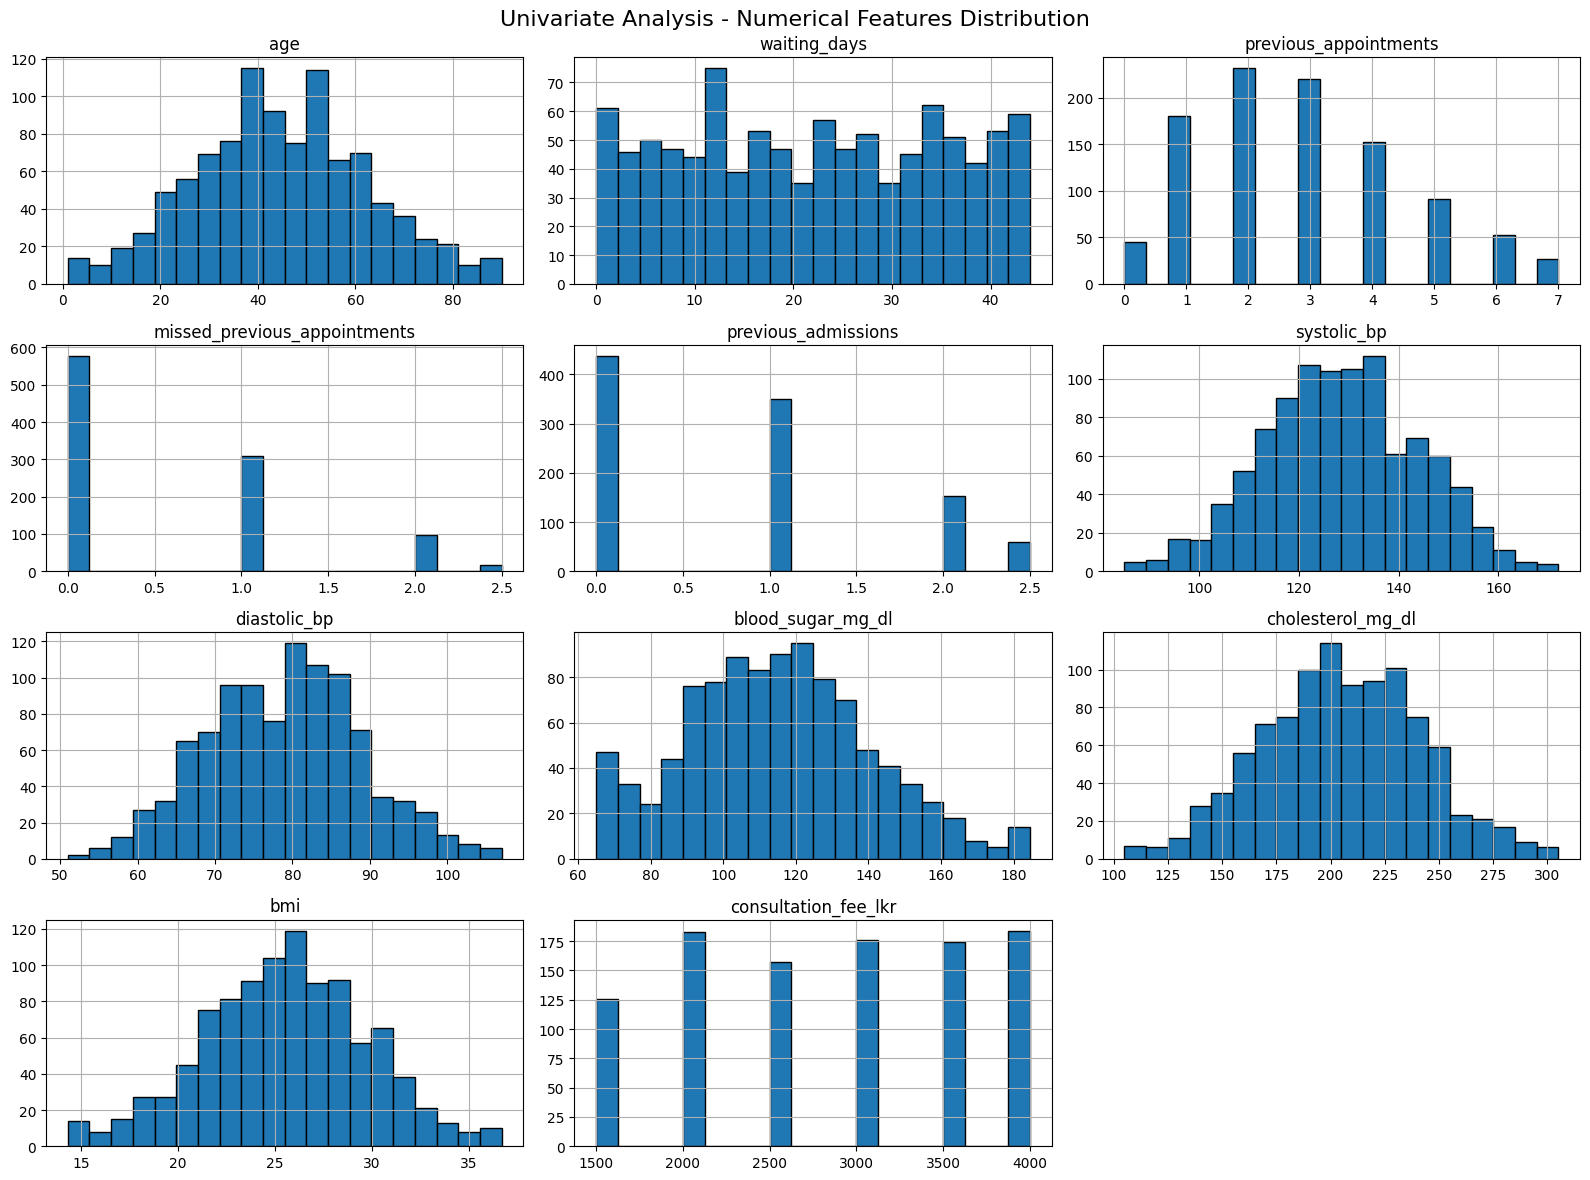

In [6]:
numeric_cols = [
    "age",
    "waiting_days",
    "previous_appointments",
    "missed_previous_appointments",
    "previous_admissions",
    "systolic_bp",
    "diastolic_bp",
    "blood_sugar_mg_dl",
    "cholesterol_mg_dl",
    "bmi",
    "consultation_fee_lkr"
]

df[numeric_cols].hist(figsize=(16, 12), bins=20, edgecolor='black')
plt.suptitle("Univariate Analysis - Numerical Features Distribution", fontsize=16)
plt.tight_layout()
plt.show()

### Bivariate & Categorical Analysis

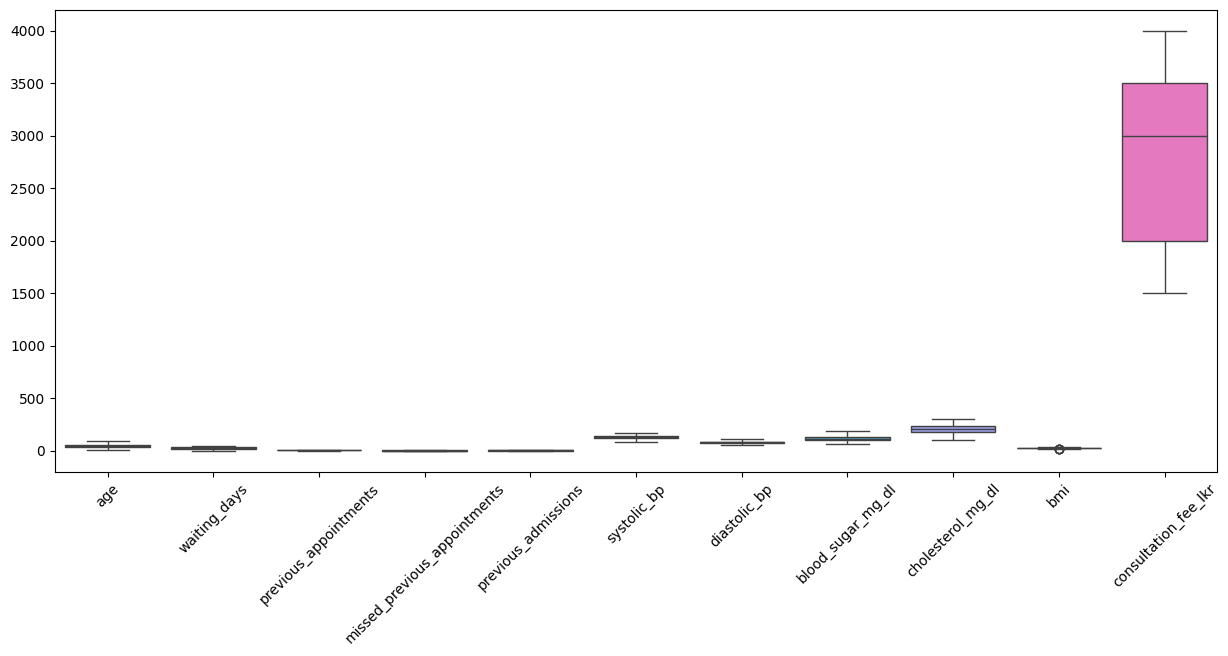

In [7]:
plt.figure(figsize=(15,6))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=45)

plt.show()

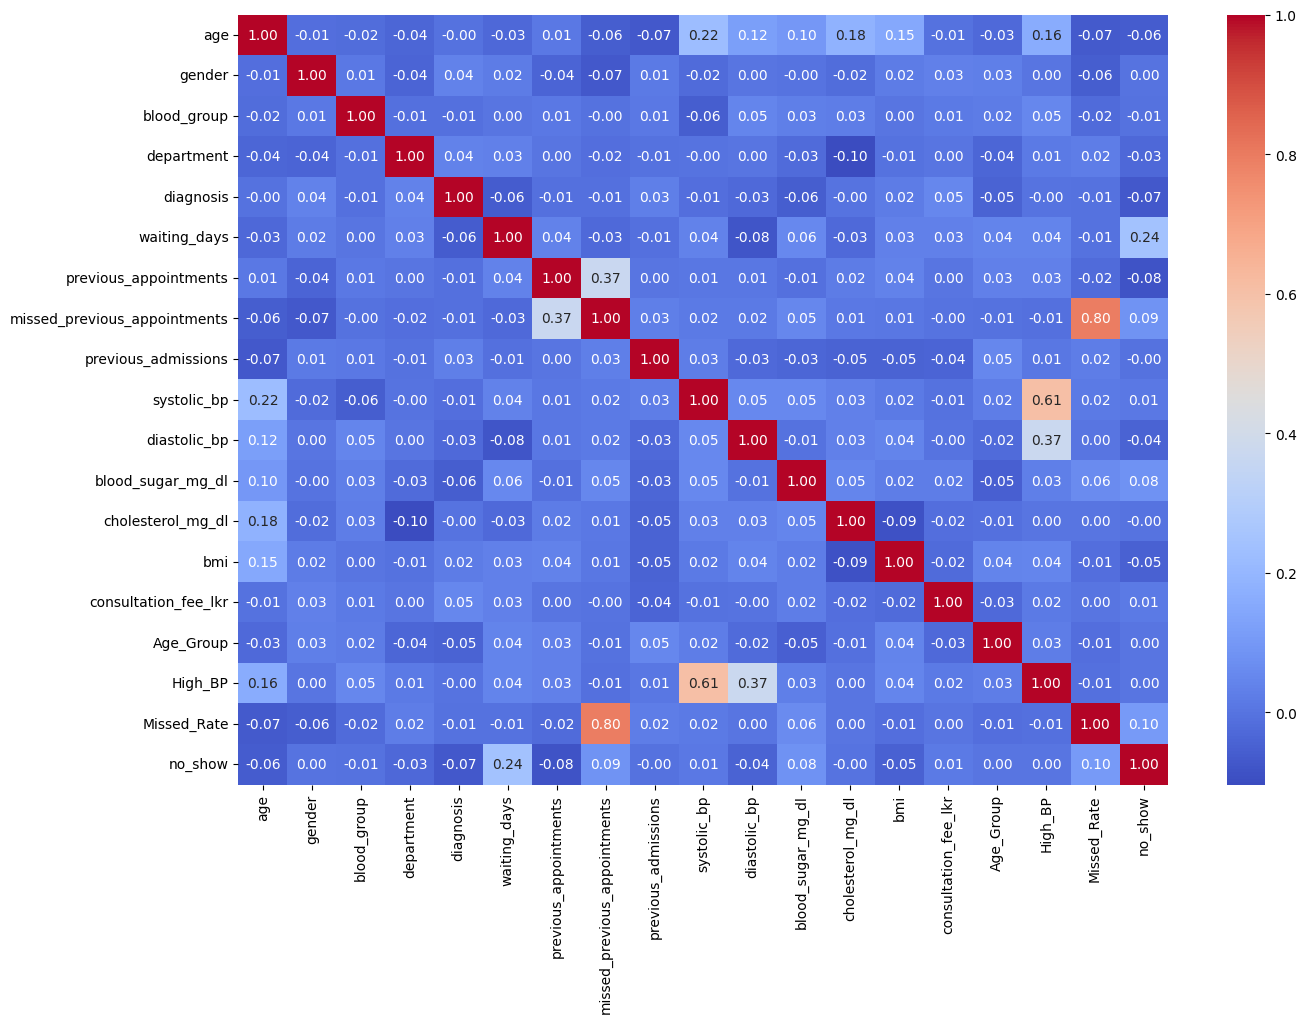

In [8]:
plt.figure(figsize=(15,10))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.show()

## Scatter plot

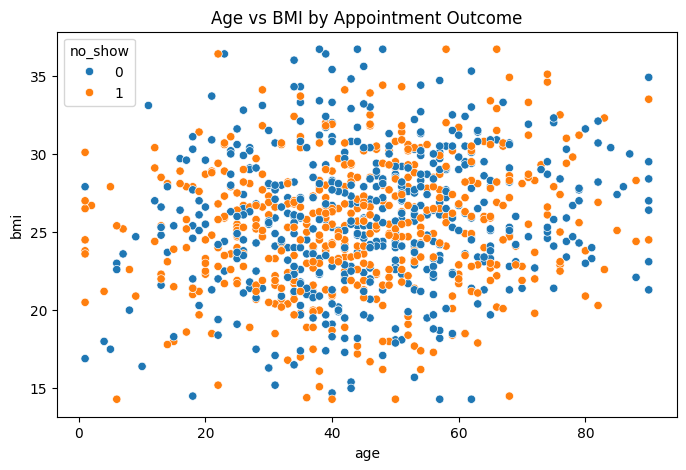

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="age", y="bmi", hue="no_show")
plt.title("Age vs BMI by Appointment Outcome")
plt.show()

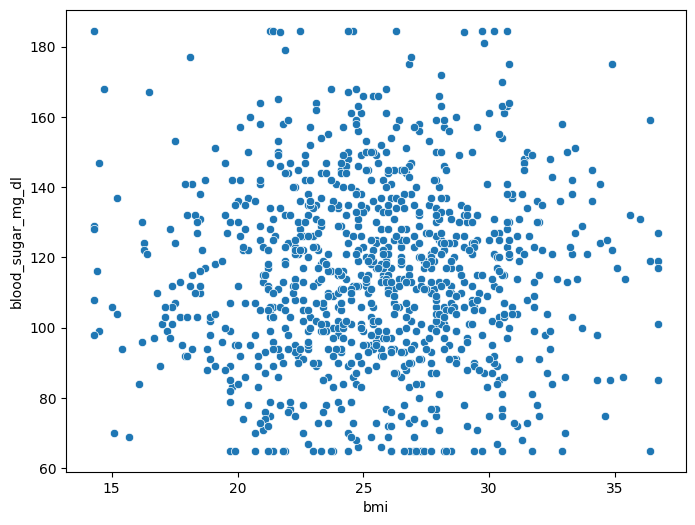

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="bmi",
    y="blood_sugar_mg_dl",
    data=df
)

plt.show()

### Categorical Feature Counts

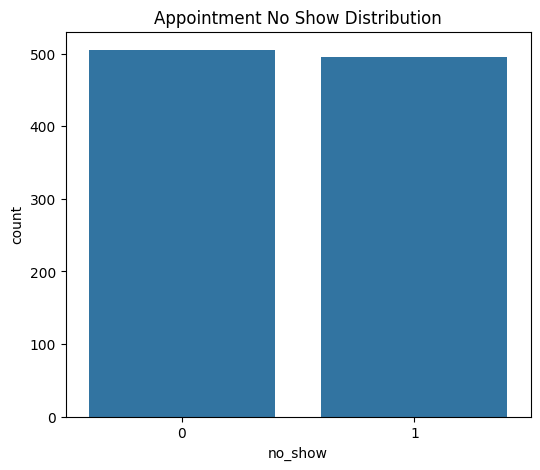

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(x="no_show", data=df)

plt.title("Appointment No Show Distribution")

plt.show()

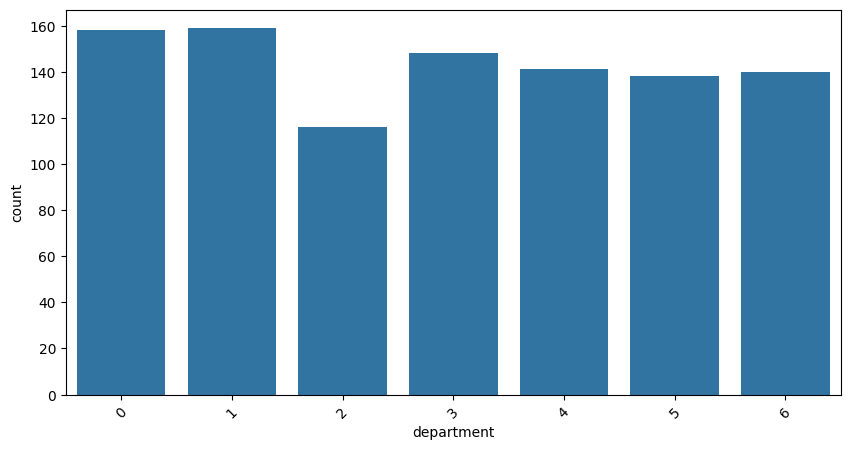

In [12]:
plt.figure(figsize=(10,5))

sns.countplot(x="department", data=df)

plt.xticks(rotation=45)

plt.show()

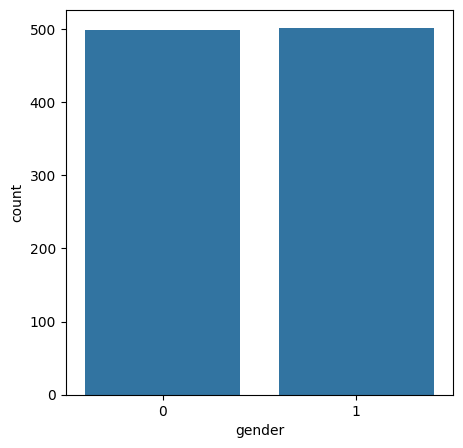

In [13]:
plt.figure(figsize=(5,5))

sns.countplot(x="gender", data=df)

plt.show()

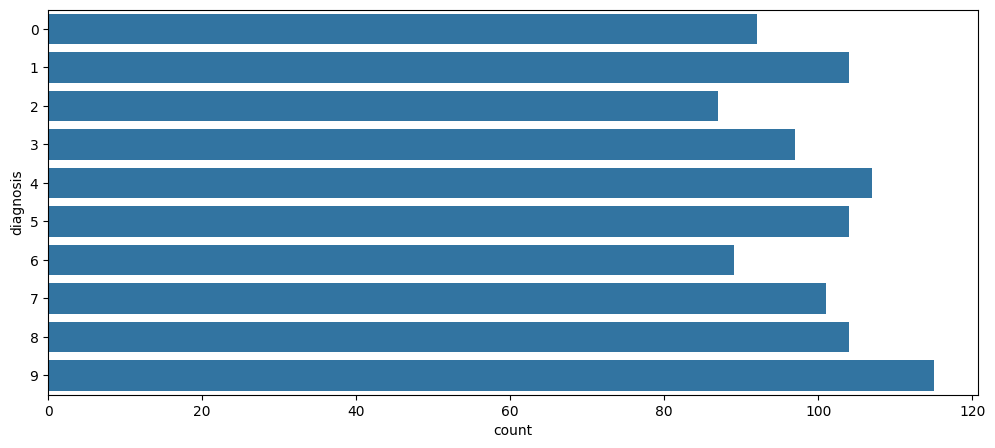

In [14]:
plt.figure(figsize=(12,5))

sns.countplot(y="diagnosis", data=df)

plt.show()

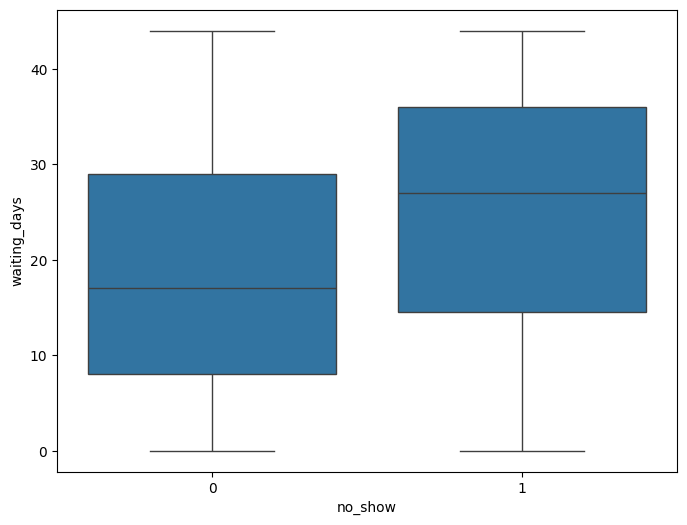

In [15]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="no_show",
    y="waiting_days",
    data=df
)

plt.show()

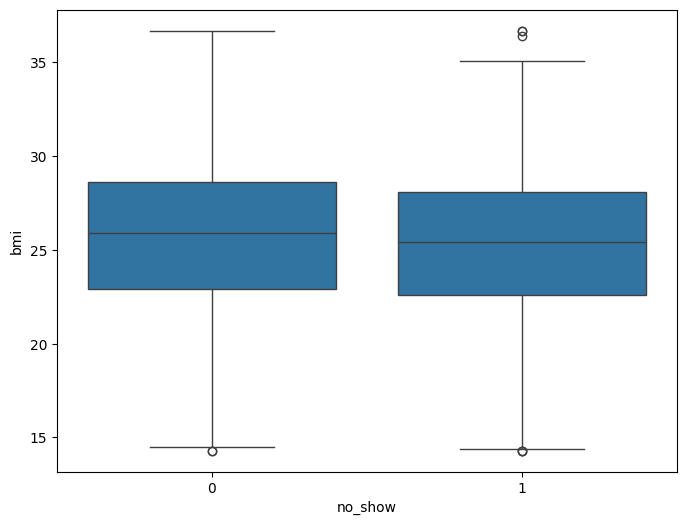

In [16]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="no_show",
    y="bmi",
    data=df
)

plt.show()

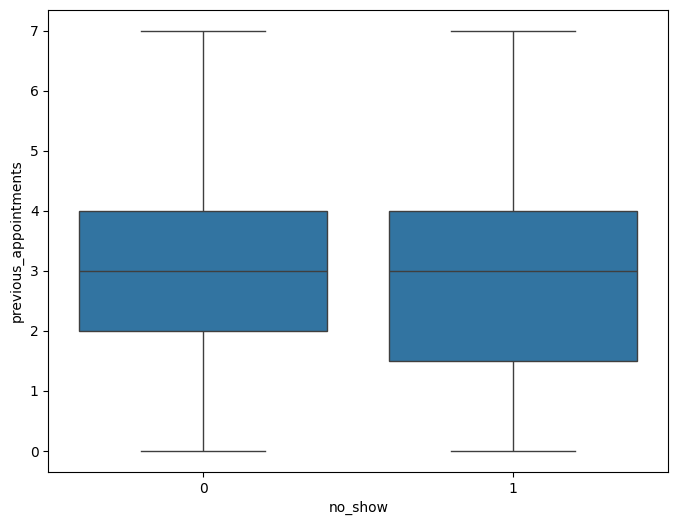

In [17]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="no_show",
    y="previous_appointments",
    data=df
)

plt.show()

### Pairplot Analysis

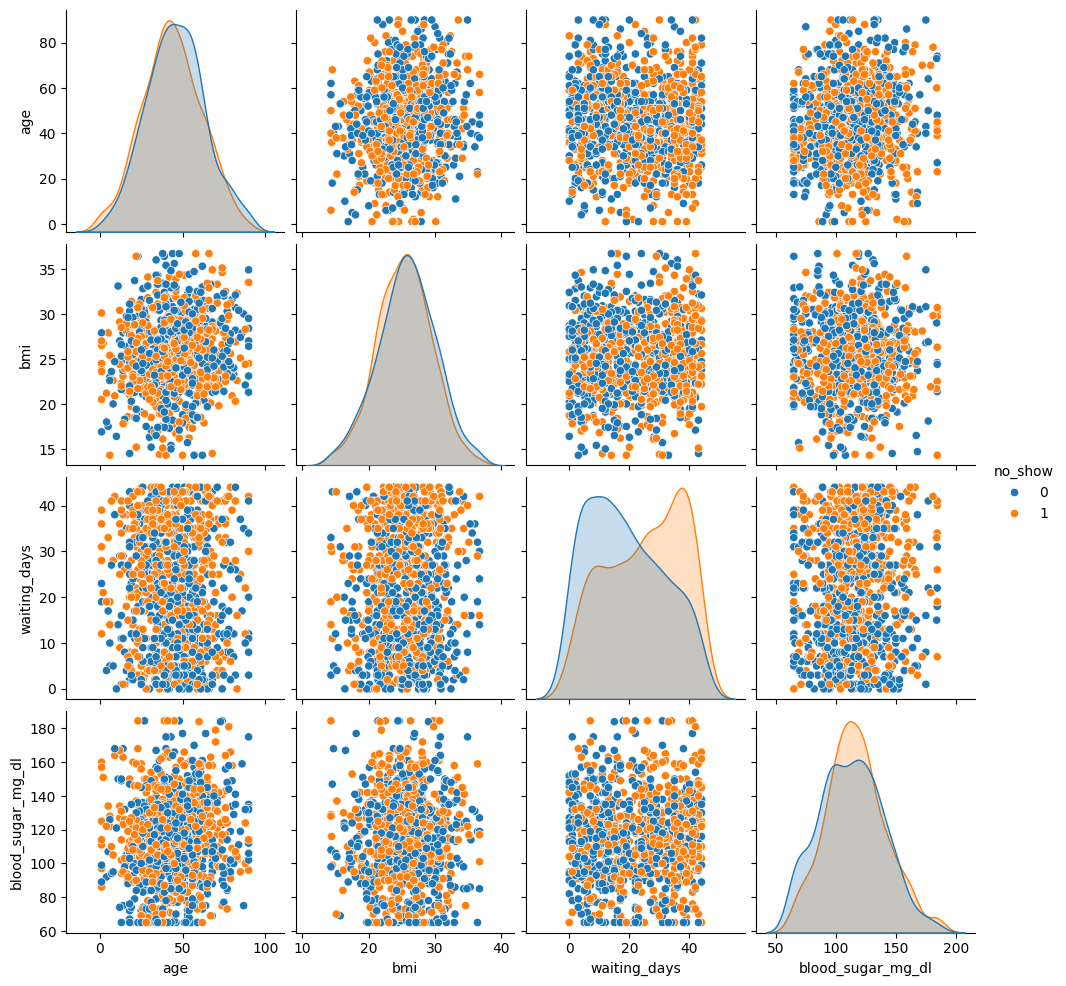

In [18]:
sns.pairplot(
    df[
        [
            "age",
            "bmi",
            "waiting_days",
            "blood_sugar_mg_dl",
            "no_show"
        ]
    ],
    hue="no_show"
)

plt.show()